In [ ]:
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
from matplotlib.gridspec import GridSpec as gs
import matplotlib.pyplot as plt


engine = create_engine(
    "postgresql+psycopg2://postgres@localhost:5432/bank_customer_churn_prediction")

df = pd.read_sql(
    "select current_database();",
    engine)
display(df)

,current_database
0,bank_customer_churn_prediction


In [ ]:
df = pd.read_sql(
    """select
    *
from bank_customers""",
    engine)

print(df.head(10).to_markdown())

|    |   row_number |   customer_id | surname   |   credit_score | geography   | gender   |   age |   tenure |   balance |   num_of_products |   estimated_salary |   active_user |
|---:|-------------:|--------------:|:----------|---------------:|:------------|:---------|------:|---------:|----------:|------------------:|-------------------:|--------------:|
|  0 |            1 |      15634602 | Hargrave  |            619 | France      | Female   |    42 |        2 |       0   |                 1 |           101349   |             1 |
|  1 |            2 |      15647311 | Hill      |            608 | Spain       | Female   |    41 |        1 |   83807.9 |                 1 |           112543   |             0 |
|  2 |            3 |      15619304 | Onio      |            502 | France      | Female   |    42 |        8 |  159661   |                 3 |           113932   |             1 |
|  3 |            4 |      15701354 | Boni      |            699 | France      | Female   |    39 | 

In [103]:
from scipy.stats import norm
import numpy as np

alpha = 0.05
power = 0.8
p = 0.05
n = 5000

z_alpha = norm.ppf(1 - alpha / 2)
z_beta = norm.ppf(power)

mde = (z_alpha + z_beta) * np.sqrt((2 * p * (1 - p)) / n)

print(f"MDE = {mde:.4%}")

MDE = 1.2212%


In [104]:
salt = "credit_card_a/b_test_01" 

import hashlib
def get_bucket(customer_id, salt):
    value = f"{customer_id}_{salt}"
    hash_value = hashlib.md5(value.encode()).hexdigest()
    bucket = int(hash_value, 16) % 100
    return bucket

def assign_group(customer_id, salt):
    bucket = get_bucket(customer_id, salt)
    if bucket < 50:
        return "control"
    else:
        return "test"

df["bucket"] = df["customer_id"].apply(
    lambda x: get_bucket(x, salt))


df["group"] = df["customer_id"].apply(
    lambda x: assign_group(x, salt))

display(df["group"].value_counts().sort_index())


group
control    4884
test       5116
Name: count, dtype: int64

In [105]:
print(df.head(10).to_markdown())

|    |   row_number |   customer_id | surname   |   credit_score | geography   | gender   |   age |   tenure |   balance |   num_of_products |   estimated_salary |   active_user |   bucket | group   |
|---:|-------------:|--------------:|:----------|---------------:|:------------|:---------|------:|---------:|----------:|------------------:|-------------------:|--------------:|---------:|:--------|
|  0 |            1 |      15634602 | Hargrave  |            619 | France      | Female   |    42 |        2 |       0   |                 1 |           101349   |             1 |       88 | test    |
|  1 |            2 |      15647311 | Hill      |            608 | Spain       | Female   |    41 |        1 |   83807.9 |                 1 |           112543   |             0 |       98 | test    |
|  2 |            3 |      15619304 | Onio      |            502 | France      | Female   |    42 |        8 |  159661   |                 3 |           113932   |             1 |       40 | contr

In [ ]:
control = 0.05
test = 0.07

df["booking"] = np.where(
    df["group"] == "control",
    np.random.binomial(1, control, len(df)),
    np.random.binomial(1, test, len(df)))

display(df)

,row_number,customer_id,surname,credit_score,geography,gender,age,tenure,balance,num_of_products,estimated_salary,active_user,bucket,group,booking
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,101348.88,1,88,test,0
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,112542.58,0,98,test,1
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,113931.57,1,40,control,0
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,93826.63,0,11,control,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,79084.10,0,75,test,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,96270.64,0,70,test,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,101699.77,0,30,control,1
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,42085.58,1,8,control,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,92888.52,1,76,test,0


In [ ]:
result_of_ab =(
    df.groupby("group").agg(
        total_count = ("booking", "count"),
        conversions=("booking", "sum"),
        conversion_rate=("booking", "mean")))

display(result_of_ab)


,total_count,conversions,conversion_rate
group,,,
control,4884,236,0.048321
test,5116,381,0.074472


In [ ]:
from statsmodels.stats.proportion import proportions_ztest
conversions = [228, 388]
total_count = [4884, 5116]

z, p_value = proportions_ztest(
    count=conversions,
    nobs=total_count)

from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_high = confint_proportions_2indep(
    count1 = 388,
    nobs1 = 5116,
    count2 = 228,
    nobs2 = 4884,
    method="wald")

print(f"z = {z}")
print(f"p_value = {p_value}")
print(f"95% CI = [{ci_low:.4%}; {ci_high:.4%}]")


z = -6.062033537053886
p_value = 1.3441117797251038e-09
95% CI = [1.9796%; 3.8519%]


In [110]:
result_of_ab =(
    df.groupby("group").agg(
        total_count = ("booking", "count"),
        conversions=("booking", "sum"),
        conversion_rate=("booking", "mean")))

display(result_of_ab)


,total_count,conversions,conversion_rate
group,,,
control,4884,236,0.048321
test,5116,381,0.074472


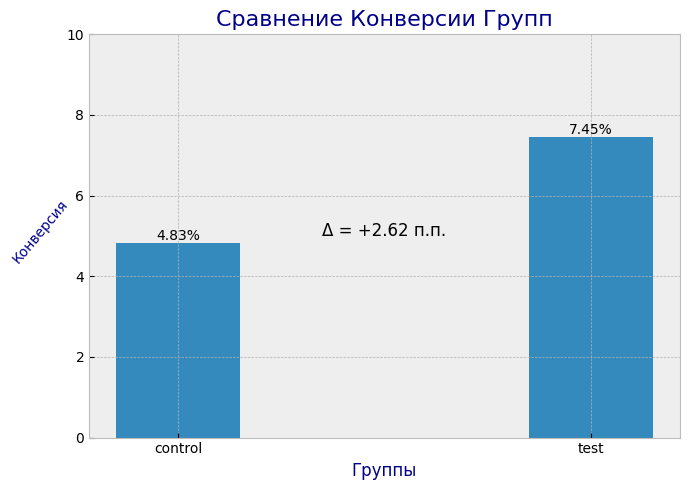

In [186]:
fig, ax = plt.subplots(figsize=(7, 5))
plt.style.use('bmh')
bars = ax.bar(result_of_ab.index, 
       result_of_ab["conversion_rate"] * 100,
       width = 0.3)

ax.set_title("Сравнение Конверсии Групп", color = 'darkblue', fontsize = 16)
ax.set_xlabel("Группы", color = 'darkblue')
ax.set_ylabel("Конверсия", rotation = 50, labelpad = 15, fontsize = 10, color = 'darkblue')
ax.set_ylim(0, 10)
plt.bar_label(bars,
              fmt = '%.2f%%')

ax.text(0.5, 5, 'Δ = +2.62 п.п.', ha='center', fontsize=12)

plt.tight_layout()


